<a href="https://colab.research.google.com/github/servetgencimli-dotcom/DataScience/blob/main/Detect_Crop_Diseases_Using_Aerial_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('meta_deta.csv')

In [ ]:
df

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3
...,...,...
21392,999068805.jpg,3
21393,999329392.jpg,3
21394,999474432.jpg,1
21395,999616605.jpg,4


In [ ]:
df.isnull().sum()

image_id    0
label       0
dtype: int64

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

In [ ]:
image_folder = "images"

# yeni dataset folderi
base_dir = "dataset"

# split
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

splits = {
    "train": train_df,
    "valid": valid_df,
    "test": test_df
}

# class folderləri yaradiram
classes = df["label"].unique()

for split in splits:
    for cls in classes:
        os.makedirs(
            os.path.join(base_dir, split, str(cls)),
            exist_ok=True
        )

# şəkilləri köçürurem
for split_name, split_df in splits.items():

    for _, row in split_df.iterrows():

        image_name = row["image_id"]
        label = str(row["label"])

        src = os.path.join(image_folder, image_name)

        dst = os.path.join(
            base_dir,
            split_name,
            label,
            image_name
        )

        if os.path.exists(src):
            shutil.copy(src, dst)

print("Dataset hazırdır.")

Dataset hazırdır.


In [ ]:
from torchvision.datasets  import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
train_data = ImageFolder("dataset/train", transform=train_transform)
val_data = ImageFolder("dataset/valid", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 5)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:


class_counts = torch.tensor([142, 280, 309, 1668, 333], dtype=torch.float)

weights = 1.0 / class_counts
weights = weights / weights.sum()

print(weights)
criterion = nn.CrossEntropyLoss(weight=weights.to(device), label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


tensor([0.4035, 0.2046, 0.1854, 0.0344, 0.1721])


In [ ]:
for epoch in range(10):

    model.train()
    total_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.9938056863496958
Epoch 2, Loss: 0.7283093201990573
Epoch 3, Loss: 0.6035184497351473
Epoch 4, Loss: 0.5064204630533649
Epoch 5, Loss: 0.42342414054537064
Epoch 6, Loss: 0.3251094011773254
Epoch 7, Loss: 0.24337636912000302
Epoch 8, Loss: 0.18280420492408034
Epoch 9, Loss: 0.15759741094137103
Epoch 10, Loss: 0.13710073848288756


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print('Classification Report\n',classification_report(y_true, y_pred))
print("Confusion Matrix\n", confusion_matrix(y_true, y_pred))
print('Accuracy Score',accuracy_score(y_true, y_pred))

Classification Report
               precision    recall  f1-score   support

           0       0.52      0.60      0.56       126
           1       0.76      0.73      0.74       255
           2       0.70      0.73      0.71       262
           3       0.96      0.92      0.94      1473
           4       0.59      0.69      0.64       291

    accuracy                           0.83      2407
   macro avg       0.71      0.73      0.72      2407
weighted avg       0.84      0.83      0.84      2407

Confusion Matrix
 [[  75   13    3    4   31]
 [  20  185    8   14   28]
 [   6    7  191   24   34]
 [   6   20   54 1348   45]
 [  37   19   18   15  202]]
Accuracy Score 0.8313253012048193


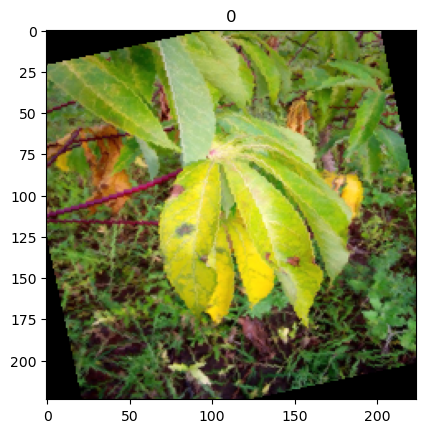

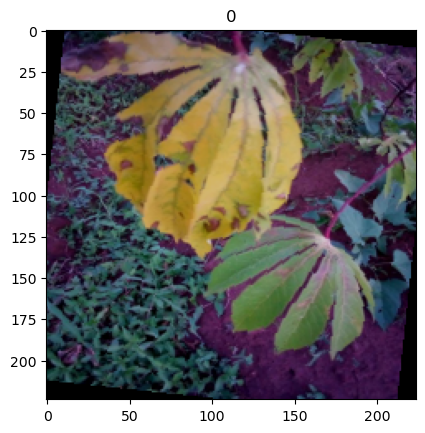

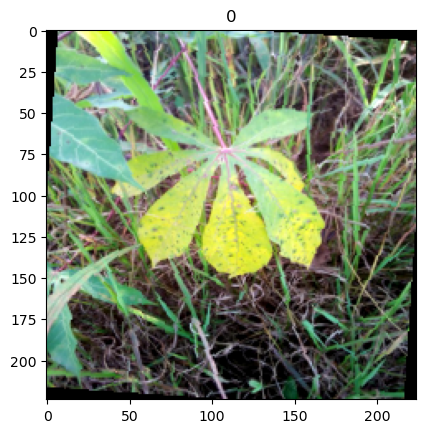

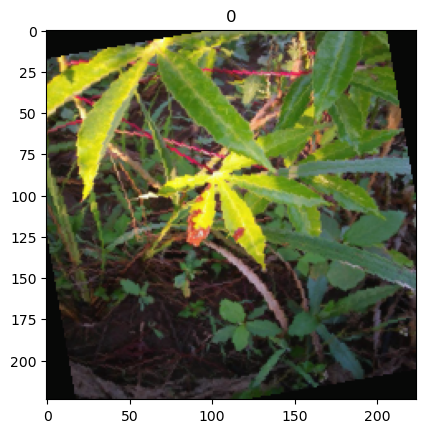

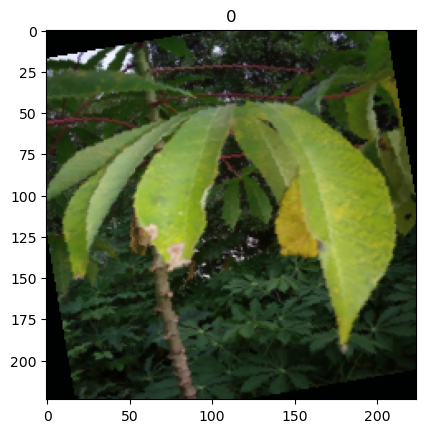

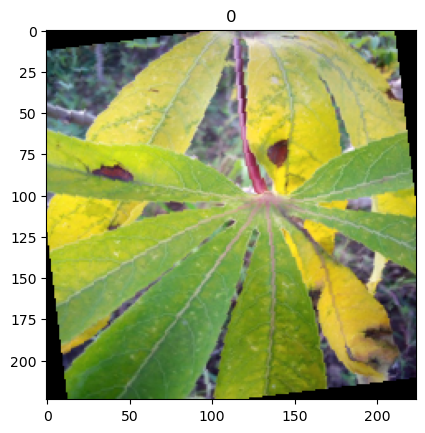

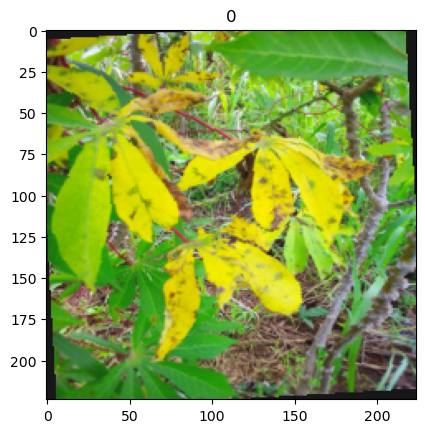

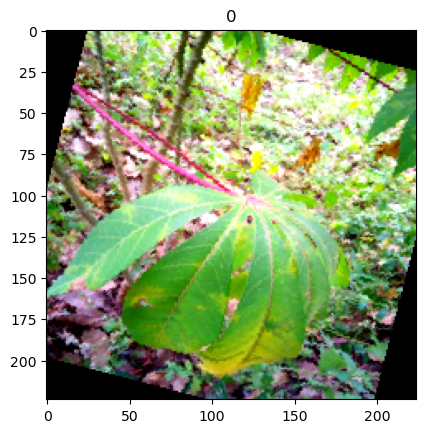

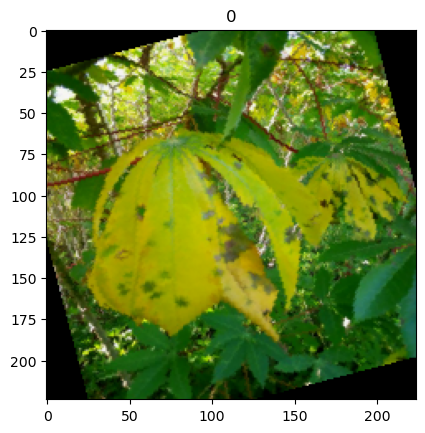

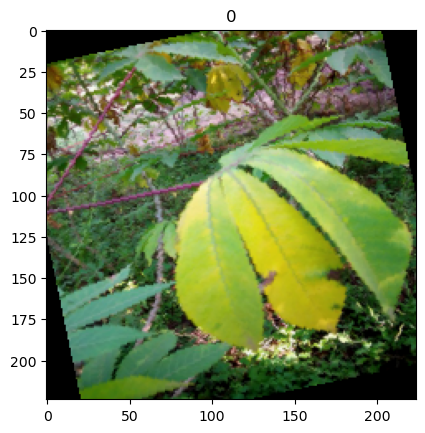

In [ ]:
for i in range(10):
    img, label = train_data[i]
    # Denormalize image for correct color visualization
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img_denorm = inv_normalize(img)
    plt.imshow(img_denorm.permute(1,2,0).clamp(0, 1))
    plt.title(label)
    plt.show()